# AlexNet Benchmark

use PY310, py311 not support torch.compile, py39 not support libnvrtc.so compatibility

In [1]:
model_name = "ResNet101"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll


In [2]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Prepare

In [3]:
#recompute, storeall = [
#    ragdoll.compile(x, "gpu", "input", "codegen", benchmark=True) for x in ["recompute.mlir", "storeall.mlir"]
#]
#recompute = ragdoll.compile("recompute.mlir", "gpu", "input", "codegen", benchmark=True)
#storeall = ragdoll.compile("storeall.mlir", "gpu", "input", "codegen", benchmark=True)
!iree-compile recompute.mlir \
-o recompute.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86

!iree-compile storeall.mlir \
-o storeall.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86
recompute = "recompute.vmfb"
storeall = "storeall.vmfb"

In [4]:
def load_executable(fb_file):
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo

#recompute_fb, storeall_fb = [
#    load_executable(x) for x in [recompute, storeall]
#]
recompute_fb = load_executable("recompute.vmfb")
storeall_fb = load_executable("storeall.vmfb")

## Experimental

In [5]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

model = models.resnet101().train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model_dynamo = torch.compile(model, backend="inductor")

device = torch.device("cuda:0")
image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)
model_native = model.to(device)

output_native = model_native(image)
output_dynamo = model_dynamo(image)
grad = torch.randn_like(output_native)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()

df = pd.DataFrame()

### PyTorch (Baseline)

In [6]:
baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output_dynamo, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-dynamo-gpu-forward:  [8.522081791478046, 8.48777816795251, 8.489351171781035, 8.472926859908243, 8.470469921389046, 8.469998891301016, 8.469585164943162, 8.464830817983431, 8.467753472573618, 8.504854898680659, 8.509072310784283]
8.484427588070458
torch-dynamo-gpu-backward:  [9.58213149843847, 8.60603920677129, 8.604381288237432, 8.616394801613163, 8.598521844867397, 8.59755595379016, 8.57669608119656, 8.592361858224168, 8.580832249101471, 8.585105650126934, 8.590418735847754]
8.684585378928618
        time      pass          item
0   8.484428   Forward  Torch Dynamo
0   8.684585  Backward  Torch Dynamo
0  17.169013      Full  Torch Dynamo


### Nabla without Optim

In [7]:
f1 = []
for i in range(11):
  f1 += [timeit("recompute_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    recompute,
    "forward",
    [(1, 3, 224, 224)], 
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)


print('ragdoll-opt1-gpu-forward in benchmark: ', f2)

f2 = np.mean(f2)

print(f1)
print(f2)

ragdoll-opt1-gpu-forward in timeit:  [0.31781460487228985, 0.30952829538899307, 0.30856067095609274, 0.30940158895271663, 0.3087417354040286, 0.30970276936012153, 0.30744593261795883, 0.30718416249489083, 0.3070175675127436, 0.3074740092543995, 0.30697688405566353]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [0.242, 0.242, 0.242, 0.242, 0.242, 0.242, 0.242, 0.242, 0.242, 0.243, 0.243]
0.30907711098817264
0.24218181818181816


In [8]:
b1 = []
for i in range(11):
    b1 += [timeit("recompute_fb.dforward(grad_np)") /  17.0]
print('ragdoll-opt1-gpu-backward in timeit: ', b1)
# TODO(albert): unresolved value error
"""
b2 = ragdoll_model_benchmark(
    recompute,
    "dforward",
    [(1, 1000)],
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)
print(b2)
"""
df = pd.concat([df, get_dataframe(f2, np.mean(b1), "Nabla-opt1")])
print(df)

ragdoll-opt1-gpu-backward in timeit:  [1.4316014019662844, 1.4273518280071371, 1.428254132213838, 1.4279554214547663, 1.428617585779113, 1.4281813537373262, 1.427728885456043, 1.4278902173699701, 1.430592392297352, 1.4301560364444466, 1.4297381213263554]
        time      pass          item
0   8.484428   Forward  Torch Dynamo
0   8.684585  Backward  Torch Dynamo
0  17.169013      Full  Torch Dynamo
0   0.242182   Forward    Nabla-opt1
0   1.428915  Backward    Nabla-opt1
0   1.671097      Full    Nabla-opt1


### Nabla with Optim

In [9]:
f1 = []
for i in range(11):
  f1 += [timeit("storeall_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    storeall,
    "forward",
    [(1, 3, 224, 224)], 
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)
print('ragdoll-opt1-gpu-forward in benchmark: ', f2)

b1 = []
for i in range(11):
    b1 += [timeit("storeall_fb.dforward(grad_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', b1)
b1 = np.mean(b1)


df = pd.concat([df, get_dataframe(np.mean(f2), b1, "Nabla-opt2")])
print(df)

ragdoll-opt1-gpu-forward in timeit:  [0.50936514073435, 0.5087602965752868, 0.5085246889468502, 0.5084971530253396, 0.5085950826897341, 0.5086596753886518, 0.5088673844276106, 0.5086294539711055, 0.5086330658591846, 0.5085757752770886, 0.5085469612523037]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [0.47400000000000003, 0.47400000000000003, 0.47400000000000003, 0.47400000000000003, 0.47400000000000003, 0.47400000000000003, 0.47400000000000003, 0.47400000000000003, 0.47400000000000003, 0.47400000000000003, 0.47400000000000003]
ragdoll-opt1-gpu-forward in timeit:  [1.1320774974849295, 1.1301012430340052, 1.1299235576435047, 1.1302373739068998, 1.1313665707540863, 1.133177880307331, 1.1331873228225637, 1.1326772023868912, 1.133083048660089, 1.133342242854483, 1.1326984014800365]
        time      pass          item
0   8.484428   Forward  Torch Dynamo
0   8.684585  Backward  Torch Dynamo
0  17.169013      Full  Torch Dynamo
0   0.242182   Forward    Nabla-

In [10]:
df.style.hide(axis="index")

time,pass,item
8.484428,Forward,Torch Dynamo
8.684585,Backward,Torch Dynamo
17.169013,Full,Torch Dynamo
0.242182,Forward,Nabla-opt1
1.428915,Backward,Nabla-opt1
1.671097,Full,Nabla-opt1
0.474000,Forward,Nabla-opt2
1.131988,Backward,Nabla-opt2
1.605988,Full,Nabla-opt2


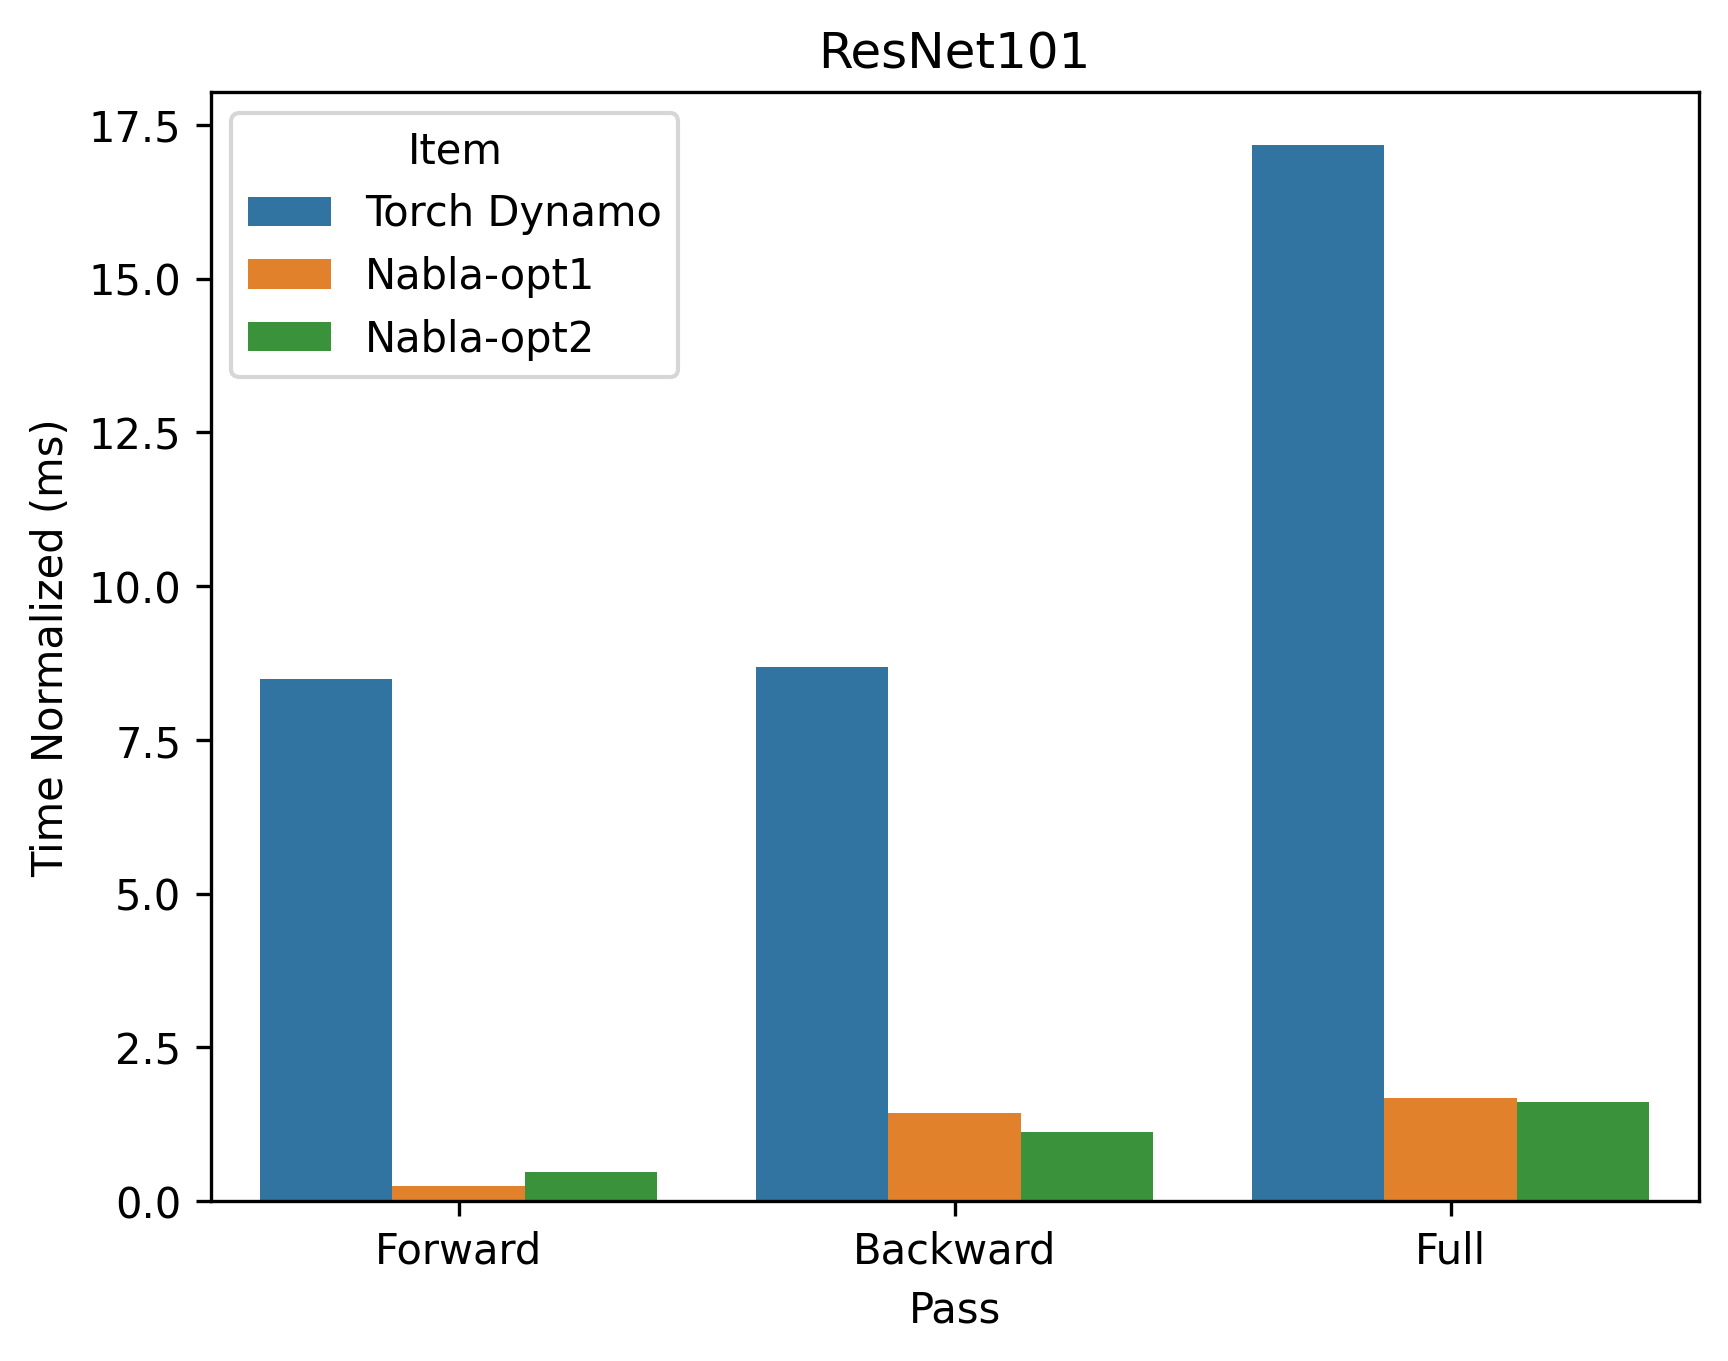

In [11]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [12]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,8.484428,Forward,Torch Dynamo,1.000000
0,0.242182,Forward,Nabla-opt1,35.033297
0,0.474000,Forward,Nabla-opt2,17.899636


In [13]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,8.684585,Backward,Torch Dynamo,1.000000
0,1.428915,Backward,Nabla-opt1,6.077747
0,1.131988,Backward,Nabla-opt2,7.671974


In [14]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,17.169013,Full,Torch Dynamo,1.000000
0,1.671097,Full,Nabla-opt1,10.274097
0,1.605988,Full,Nabla-opt2,10.690621


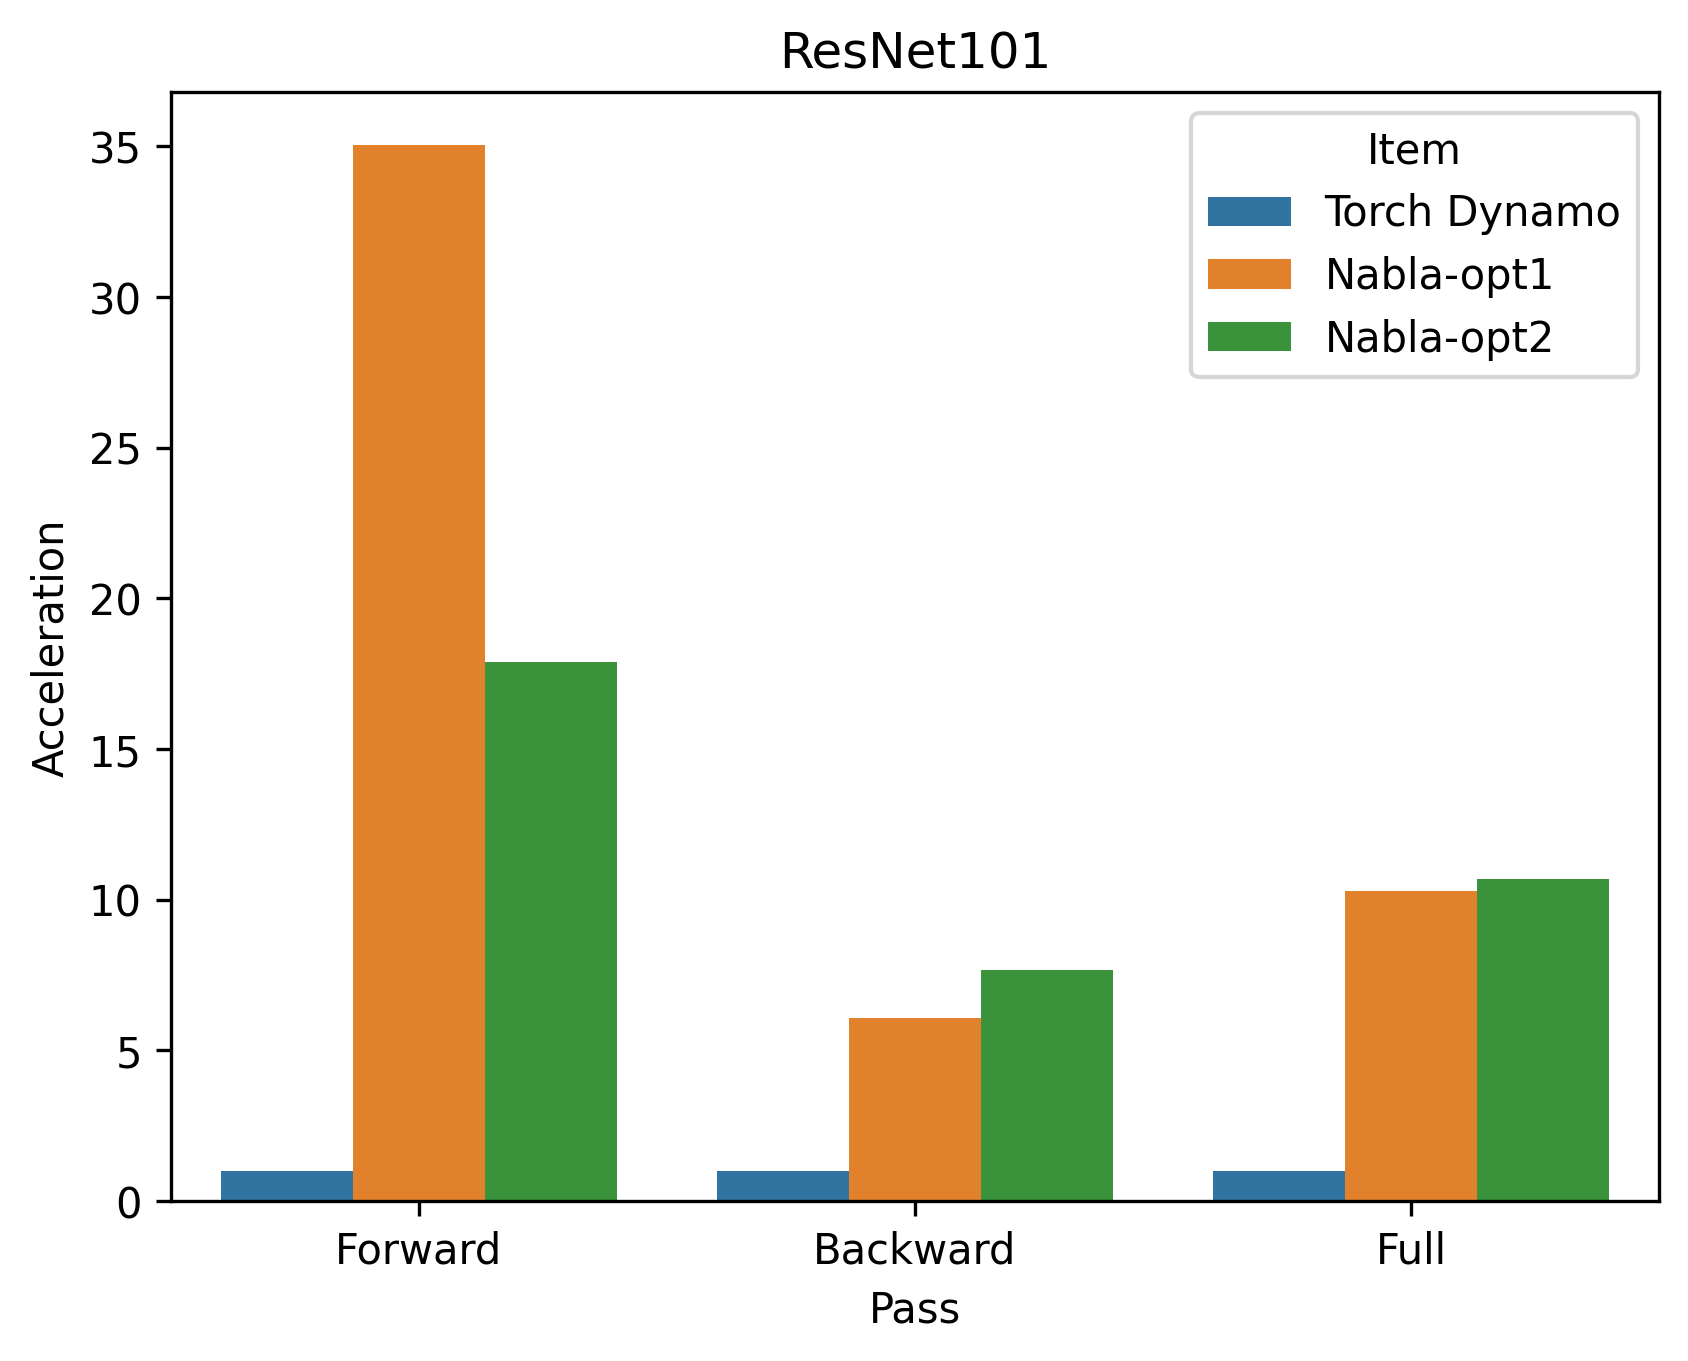

In [15]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")